<a href="https://colab.research.google.com/github/TechnoAceX/Diabetes/blob/main/Diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Data manipulation & visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Preprocessing & Model Evaluation
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC  # or: from sklearn import svm (choose one style)
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

In [ ]:
# Load the dataset
diabetes_dataset = pd.read_csv('diabetes.csv')

In [ ]:
# Display first 5 rows
diabetes_dataset.head()

,id,chol,stab.glu,hdl,ratio,glyhb,location,age,gender,height,weight,frame,bp.1s,bp.1d,bp.2s,bp.2d,waist,hip,time.ppn
0,1000,203.0,82,56.0,3.6,4.31,Buckingham,46,female,62.0,121.0,medium,118.0,59.0,NaN,NaN,29.0,38.0,720.0
1,1001,165.0,97,24.0,6.9,4.44,Buckingham,29,female,64.0,218.0,large,112.0,68.0,NaN,NaN,46.0,48.0,360.0
2,1002,228.0,92,37.0,6.2,4.64,Buckingham,58,female,61.0,256.0,large,190.0,92.0,185.0,92.0,49.0,57.0,180.0
3,1003,78.0,93,12.0,6.5,4.63,Buckingham,67,male,67.0,119.0,large,110.0,50.0,NaN,NaN,33.0,38.0,480.0
4,1005,249.0,90,28.0,8.9,7.72,Buckingham,64,male,68.0,183.0,medium,138.0,80.0,NaN,NaN,44.0,41.0,300.0


In [ ]:
# Display dataset shape (rows, columns)
diabetes_dataset.shape

(403, 19)

In [ ]:
# Get dataset statistics
diabetes_dataset.describe()

,id,chol,stab.glu,hdl,ratio,glyhb,age,height,weight,bp.1s,bp.1d,bp.2s,bp.2d,waist,hip,time.ppn
count,403.000000,402.000000,403.000000,402.000000,402.000000,390.000000,403.000000,398.000000,402.000000,398.000000,398.000000,141.000000,141.000000,401.000000,401.000000,400.000000
mean,15978.310174,207.845771,106.672457,50.445274,4.521642,5.589769,46.851117,66.020101,177.592040,136.904523,83.321608,152.382979,92.524823,37.900249,43.039900,341.250000
std,11881.122124,44.445557,53.076655,17.262626,1.727886,2.242595,16.312333,3.918515,40.340666,22.741033,13.589227,21.712952,11.555198,5.729313,5.656713,309.540953
min,1000.000000,78.000000,48.000000,12.000000,1.500000,2.680000,19.000000,52.000000,99.000000,90.000000,48.000000,110.000000,60.000000,26.000000,30.000000,5.000000
25%,4792.500000,179.000000,81.000000,38.000000,3.200000,4.380000,34.000000,63.000000,151.000000,121.250000,75.000000,138.000000,84.000000,33.000000,39.000000,90.000000
50%,15766.000000,204.000000,89.000000,46.000000,4.200000,4.840000,45.000000,66.000000,172.500000,136.000000,82.000000,149.000000,92.000000,37.000000,42.000000,240.000000
75%,20336.000000,230.000000,106.000000,59.000000,5.400000,5.600000,60.000000,69.000000,200.000000,146.750000,90.000000,161.000000,100.000000,41.000000,46.000000,517.500000
max,41756.000000,443.000000,385.000000,120.000000,19.299999,16.110001,92.000000,76.000000,325.000000,250.000000,124.000000,238.000000,124.000000,56.000000,64.000000,1560.000000


In [ ]:
diabetes_dataset['Outcome'] = (diabetes_dataset['glyhb'] >= 6.5).astype(int)

In [ ]:
diabetes_dataset['Outcome'].value_counts()

,count
Outcome,
0,338
1,65


In [ ]:
print(diabetes_dataset.dtypes)

id            int64
chol        float64
stab.glu      int64
hdl         float64
ratio       float64
glyhb       float64
location     object
age           int64
gender       object
height      float64
weight      float64
frame        object
bp.1s       float64
bp.1d       float64
bp.2s       float64
bp.2d       float64
waist       float64
hip         float64
time.ppn    float64
Outcome       int64
dtype: object


In [ ]:
diabetes_dataset.groupby('Outcome').mean(numeric_only=True)

,id,chol,stab.glu,hdl,ratio,glyhb,age,height,weight,bp.1s,bp.1d,bp.2s,bp.2d,waist,hip,time.ppn
Outcome,,,,,,,,,,,,,,,,
0,15933.417160,203.801187,90.727811,51.400593,4.306825,4.730400,44.624260,65.997006,174.961538,134.6997,83.042042,151.481481,93.268519,37.345238,42.702381,337.164179
1,16211.753846,228.815385,189.584615,45.492308,5.635385,9.886615,58.430769,66.140625,191.484375,148.2000,84.753846,155.333333,90.090909,40.769231,44.784615,362.307692


In [ ]:
# Display mean values for each cl
numeric_cols = diabetes_dataset.select_dtypes(include=['number'])
diabetes_dataset.groupby('Outcome')[numeric_cols.columns].mean()

,id,chol,stab.glu,hdl,ratio,glyhb,age,height,weight,bp.1s,bp.1d,bp.2s,bp.2d,waist,hip,time.ppn,Outcome
Outcome,,,,,,,,,,,,,,,,,
0,15933.417160,203.801187,90.727811,51.400593,4.306825,4.730400,44.624260,65.997006,174.961538,134.6997,83.042042,151.481481,93.268519,37.345238,42.702381,337.164179,0.0
1,16211.753846,228.815385,189.584615,45.492308,5.635385,9.886615,58.430769,66.140625,191.484375,148.2000,84.753846,155.333333,90.090909,40.769231,44.784615,362.307692,1.0


# Data Preprocessing

In [ ]:
X = diabetes_dataset.drop(columns='Outcome', axis=1)
Y = diabetes_dataset['Outcome']

In [ ]:
# Apply Label Encoding to any categorical columns
label_encoder = LabelEncoder()
for col in X.select_dtypes(include=['object']).columns:
    X[col] = label_encoder.fit_transform(X[col])

# Now standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Check standardized data
print(X[:5])
print(Y[:5])

     id   chol  stab.glu   hdl  ratio  glyhb  location  age  gender  height  \
0  1000  203.0        82  56.0    3.6   4.31         0   46       0    62.0   
1  1001  165.0        97  24.0    6.9   4.44         0   29       0    64.0   
2  1002  228.0        92  37.0    6.2   4.64         0   58       0    61.0   
3  1003   78.0        93  12.0    6.5   4.63         0   67       1    67.0   
4  1005  249.0        90  28.0    8.9   7.72         0   64       1    68.0   

   weight  frame  bp.1s  bp.1d  bp.2s  bp.2d  waist   hip  time.ppn  
0   121.0      1  118.0   59.0    NaN    NaN   29.0  38.0     720.0  
1   218.0      0  112.0   68.0    NaN    NaN   46.0  48.0     360.0  
2   256.0      0  190.0   92.0  185.0   92.0   49.0  57.0     180.0  
3   119.0      0  110.0   50.0    NaN    NaN   33.0  38.0     480.0  
4   183.0      1  138.0   80.0    NaN    NaN   44.0  41.0     300.0  
0    0
1    0
2    0
3    0
4    1
Name: Outcome, dtype: int64


In [ ]:
#4. Splitting Data into Training and Testing Sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

In [ ]:
print(X.shape, X_train.shape, X_test.shape)

(403, 19) (322, 19) (81, 19)


# Logistic Regression

In [ ]:
imputer = SimpleImputer(strategy='mean')

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

log_model = LogisticRegression(solver='saga', max_iter=500)
log_model.fit(X_train_scaled, Y_train)


LogisticRegression(max_iter=500, solver='saga')

In [ ]:
Y_pred = log_model.predict(X_test_scaled)
log_acc = accuracy_score(Y_test, Y_pred)
print(f'Logistic Regression Accuracy: {log_acc:.4f}')


Logistic Regression Accuracy: 0.9753


# Support Vector Machine (SVM)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Initialize the SVM model with a linear kernel
svm_model = SVC(kernel='linear', max_iter=500)

# Train the SVM model on the scaled data
svm_model.fit(X_train_scaled, Y_train)

# Make predictions and calculate accuracy
svm_acc = round(accuracy_score(svm_model.predict(X_test_scaled), Y_test), 2)

# Print the accuracy
print(f"SVM Model Accuracy: {svm_acc}")

SVM Model Accuracy: 0.98


/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


# Random Forest

In [ ]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Initialize the Random Forest model
rf_model = RandomForestClassifier()

# Train the Random Forest model on the scaled data
rf_model.fit(X_train_scaled, Y_train)

# Make predictions and calculate accuracy
rf_acc = round(accuracy_score(rf_model.predict(X_test_scaled), Y_test), 2)

# Print the accuracy
print(f"Random Forest Model Accuracy: {rf_acc}")

Random Forest Model Accuracy: 1.0


# K-Nearest Neighbors (KNN)

In [ ]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Initialize the KNN model with 5 neighbors
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the KNN model on the scaled data
knn_model.fit(X_train_scaled, Y_train)

# Make predictions and calculate accuracy
knn_acc = round(accuracy_score(knn_model.predict(X_test_scaled), Y_test), 2)

# Print the accuracy
print(f"KNN Model Accuracy: {knn_acc}")

KNN Model Accuracy: 0.98


# Decision Tree Classifier

In [ ]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Initialize the Decision Tree model
dt_model = DecisionTreeClassifier()

# Train the Decision Tree model on the scaled data
dt_model.fit(X_train_scaled, Y_train)

# Make predictions and calculate accuracy
dt_acc = round(accuracy_score(dt_model.predict(X_test_scaled), Y_test), 2)

# Print the accuracy
print(f"Decision Tree Model Accuracy: {dt_acc}")

Decision Tree Model Accuracy: 1.0


# Naive Bayes

In [ ]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Initialize the Gaussian Naive Bayes model
nb_model = GaussianNB()

# Train the Naive Bayes model on the scaled data
nb_model.fit(X_train_scaled, Y_train)

# Make predictions and calculate accuracy
nb_acc = round(accuracy_score(nb_model.predict(X_test_scaled), Y_test), 2)

# Print the accuracy
print(f"Naive Bayes Model Accuracy: {nb_acc}")

Naive Bayes Model Accuracy: 0.99


# Deep Learning Model with TensorFlow & Keras

In [ ]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Define the neural network model
nn_model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(12, activation='relu'),
    Dropout(0.2),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile the model
nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = nn_model.fit(X_train_scaled, Y_train, epochs=50, batch_size=16, validation_data=(X_test_scaled, Y_test))

# Evaluate the model
loss, accuracy = nn_model.evaluate(X_test_scaled, Y_test)

# Print the accuracy
print(f"Neural Network Model Accuracy: {round(accuracy, 2)}")

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.7508 - loss: 0.5915 - val_accuracy: 0.8272 - val_loss: 0.4625
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7966 - loss: 0.5103 - val_accuracy: 0.8395 - val_loss: 0.4070
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8513 - loss: 0.4856 - val_accuracy: 0.8519 - val_loss: 0.3658
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8324 - loss: 0.4978 - val_accuracy: 0.8519 - val_loss: 0.3374
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8651 - loss: 0.3515 - val_accuracy: 0.8519 - val_loss: 0.3141
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8467 - loss: 0.4234 - val_accuracy: 0.8642 - val_loss: 0.3038
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8300 - loss: 0.3868 - val_accuracy: 0.8765 - val_loss: 0.2876
Epoch 8/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8524 - loss: 0.3653 - val_accuracy: 0.8765 - val_loss: 0.2714
Ep

# Evaluating the Deep Learning Model

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8338 - loss: nan
Neural Network Accuracy: 0.84


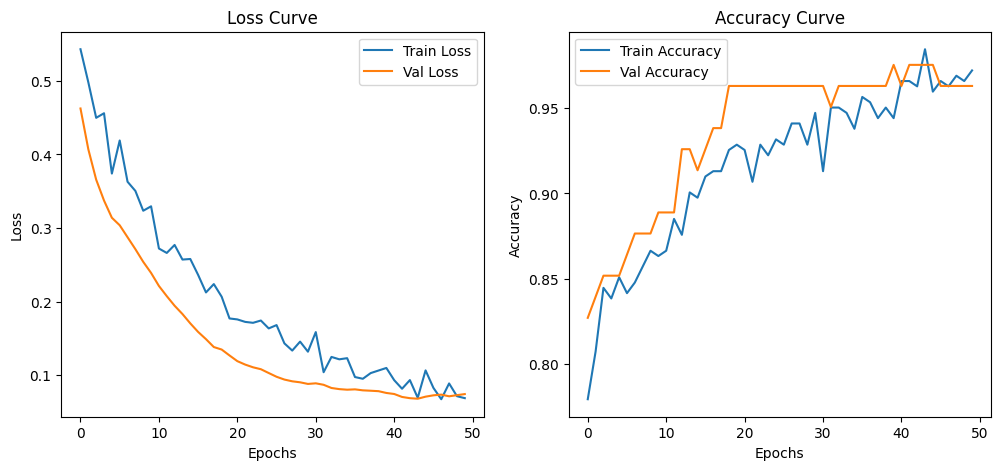

In [ ]:
# Evaluate on test data
nn_loss, nn_accuracy = nn_model.evaluate(X_test, Y_test)
print(f'Neural Network Accuracy: {round(nn_accuracy, 2)}')

# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curve')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Curve')

plt.show()


# Model Evaluation

In [ ]:
# Make predictions with the SVM model on the test data
svm_predictions = svm_model.predict(X_test_scaled)

# Print the classification report
print(classification_report(Y_test, svm_predictions))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99        68
           1       0.92      0.92      0.92        13

    accuracy                           0.98        81
   macro avg       0.95      0.95      0.95        81
weighted avg       0.98      0.98      0.98        81



# Interactive Predictive System

In [ ]:
# Assuming diabetes_dataset is already loaded
X_new = diabetes_dataset.drop(columns='Outcome', axis=1).copy()

# Add new features
X_new['family_history'] = diabetes_dataset['Outcome'].apply(lambda x: 1 if x == 1 else 0)  # Family history based on Outcome
X_new['exercise_level'] = 0  # Placeholder: Add logic for exercise level
X_new['diet'] = 0  # Placeholder: Add logic for diet (you could convert categorical data if available)

# Check the first few rows to ensure new features are added correctly
print(X_new.head())


     id   chol  stab.glu   hdl  ratio  glyhb    location  age  gender  height  \
0  1000  203.0        82  56.0    3.6   4.31  Buckingham   46  female    62.0   
1  1001  165.0        97  24.0    6.9   4.44  Buckingham   29  female    64.0   
2  1002  228.0        92  37.0    6.2   4.64  Buckingham   58  female    61.0   
3  1003   78.0        93  12.0    6.5   4.63  Buckingham   67    male    67.0   
4  1005  249.0        90  28.0    8.9   7.72  Buckingham   64    male    68.0   

   ...  bp.1s bp.1d  bp.2s  bp.2d  waist   hip  time.ppn  family_history  \
0  ...  118.0  59.0    NaN    NaN   29.0  38.0     720.0               0   
1  ...  112.0  68.0    NaN    NaN   46.0  48.0     360.0               0   
2  ...  190.0  92.0  185.0   92.0   49.0  57.0     180.0               0   
3  ...  110.0  50.0    NaN    NaN   33.0  38.0     480.0               0   
4  ...  138.0  80.0    NaN    NaN   44.0  41.0     300.0               1   

   exercise_level  diet  
0               0     0  
1   

In [ ]:
# Perform one-hot encoding for categorical features
X_new_encoded = pd.get_dummies(X_new, drop_first=True)  # drop_first=True to avoid multicollinearity

# Standardize the updated and encoded features
scaler = StandardScaler()
X_new_scaled = scaler.fit_transform(X_new_encoded)  # Now all columns are numeric

# Separate features (X) and labels (Y)
X = X_new_scaled  # Use the updated, scaled features
Y = diabetes_dataset['Outcome']  # Target variable (Outcome)

# Check the first few rows of the standardized features
print(X[:5])  # Preview the first few rows of the standardized features
print(Y[:5])  # Preview the first few labels


[[-1.26224848 -0.10916298 -0.46542354  0.32217858 -0.53405741 -0.57139754
  -0.05224112 -1.02721581 -1.4046015  -0.83234199 -1.79202398         nan
          nan -1.55539907 -0.89207213  1.22511843 -0.43852901  0.
   0.         -1.00747208 -0.84983659  1.09097085 -0.58976782]
 [-1.26216421 -0.96520696 -0.18246213 -1.53384704  1.37817072 -0.51335447
  -1.0956928  -0.51617595  1.00291634 -1.09651433 -1.12890106         nan
          nan  1.41550467  0.87794729  0.06064943 -0.43852901  0.
   0.         -1.00747208 -0.84983659 -0.91661478 -0.58976782]
 [-1.26207994  0.45402385 -0.2767826  -0.77983663  0.97254643 -0.42405759
   0.684313   -1.28273574  1.94606766  2.33772608  0.63942674  1.50754736
  -0.04558068  1.9397818   2.47096477 -0.52158508 -0.43852901  0.
   0.         -1.00747208 -0.84983659 -0.91661478 -0.58976782]
 [-1.26199566 -2.92509714 -0.25791851 -2.22985665  1.14638545 -0.42852233
   1.23672859  0.25038385 -1.45424104 -1.18457178 -2.4551469          nan
          nan -0.8563

In [ ]:
# Split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

# Display shapes
print(X.shape, X_train.shape, X_test.shape)


(403, 23) (322, 23) (81, 23)


In [ ]:
print(type(X_train))


<class 'numpy.ndarray'>


In [ ]:
# Encode categorical variables
X_new_encoded = pd.get_dummies(X_new, drop_first=True)

# Separate features (X) and labels (Y)
X = X_new_encoded  # Keep it as a DataFrame before splitting
Y = diabetes_dataset['Outcome']

# Split the data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

# Now scale the data AFTER splitting (keeping DataFrame structure)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame to retain column names
X_train_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Now you can check for categorical columns safely
print(X_train_df.dtypes)


id                 float64
chol               float64
stab.glu           float64
hdl                float64
ratio              float64
glyhb              float64
age                float64
height             float64
weight             float64
bp.1s              float64
bp.1d              float64
bp.2s              float64
bp.2d              float64
waist              float64
hip                float64
time.ppn           float64
family_history     float64
exercise_level     float64
diet               float64
location_Louisa    float64
gender_male        float64
frame_medium       float64
frame_small        float64
dtype: object


In [ ]:
# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame to retain column names
X_train_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Check if the scaling worked correctly
print(X_train_df.head())


         id      chol  stab.glu       hdl     ratio     glyhb       age  \
0  0.303018 -1.386448 -0.535917 -0.488160 -0.635997 -0.409473 -1.423505   
1  0.384685 -0.374187  0.908850  0.426873 -0.766156  1.108807 -0.930304   
2 -0.070971 -0.213145  0.214611 -0.259402 -0.115359 -0.512483  1.350750   
3  0.092194  0.477033 -0.517153 -0.774108  1.121155 -0.378122 -1.238555   
4 -0.071976 -1.202400 -0.911180  1.055958 -1.482033 -0.633408 -1.238555   

     height    weight     bp.1s  ...     waist       hip  time.ppn  \
0 -1.266395  0.195814 -0.419587  ...  0.892553  0.702902  0.918325   
1 -1.010370  1.498017  0.192471  ...  2.629882  2.310813 -0.286731   
2 -0.754345 -1.331770 -0.278343  ... -1.018509 -0.905008 -0.889258   
3  1.549881  2.048950 -0.654993  ...  1.761217  1.060216  1.320010   
4  1.805906 -0.079652 -1.219969  ... -1.365975 -1.440978 -0.487573   

   family_history  exercise_level  diet  location_Louisa  gender_male  \
0       -0.438854             0.0   0.0          -1.012

In [ ]:
# ------------------------------
# 1. Handle Missing Values Before Scaling
# ------------------------------
X_train = X_train.apply(pd.to_numeric, errors='coerce')  # Convert non-numeric to NaN
X_test = X_test.apply(pd.to_numeric, errors='coerce')

# Fill missing values with the median of each column
X_train.fillna(X_train.median(), inplace=True)
X_test.fillna(X_test.median(), inplace=True)

# ------------------------------
# 2. Standardization (After Filling NaNs)
# ------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Check for NaNs after scaling
print(f"NaNs in X_train_scaled: {np.isnan(X_train_scaled).sum()}")  # Should be 0
print(f"NaNs in X_test_scaled: {np.isnan(X_test_scaled).sum()}")  # Should be 0

# ------------------------------
# 3. Train Logistic Regression
# ------------------------------
log_model = LogisticRegression(solver='saga', max_iter=500)
log_model.fit(X_train_scaled, Y_train)

# Evaluate the model
train_acc = log_model.score(X_train_scaled, Y_train)
test_acc = log_model.score(X_test_scaled, Y_test)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy: {test_acc:.4f}")


NaNs in X_train_scaled: 0
NaNs in X_test_scaled: 0
Training Accuracy: 1.0000
Testing Accuracy: 1.0000


In [ ]:
import numpy as np

def predict_diabetes(features):
    features = np.array(features).reshape(1, -1)  # Reshape to match model input
    features_scaled = scaler.transform(features)  # Standardize input
    prediction = log_model.predict(features_scaled)  # Make prediction
    return "Diabetic" if prediction[0] == 1 else "Non-Diabetic"

# Check the expected feature count
expected_features = X_train_scaled.shape[1]
print(f"Model expects {expected_features} features.")

# Example input (Ensure it matches the expected feature count)
user_input = np.array([180, 120, 5.1, 45, 2.3, 4.5, 50, 170, 70, 130, 85, 120, 80, 90, 95, 2.5, 1, 1, 0, 0, 1, 0])  # Ensure correct length

# Verify input length
if len(user_input) != expected_features:
    print(f"Error: Expected {expected_features} features but got {len(user_input)}.")
else:
    result = predict_diabetes(user_input)
    print(f"Prediction: {result}")


Model expects 23 features.
Error: Expected 23 features but got 22.


In [ ]:
# Inspect the shape of X_train before any transformations
print("Shape of X_train before handling missing data:", X_train.shape)

# Convert non-numeric columns to numeric, set errors to NaN if any
X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_test = X_test.apply(pd.to_numeric, errors='coerce')

# Check for missing values before filling
print("Missing values in X_train before filling:", X_train.isnull().sum())

# Fill missing values with the median of each column
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_test.median())

# Verify there are no missing values after filling
print("Missing values in X_train after filling:", X_train.isnull().sum())

# Inspect the shape of X_train after handling missing values
print("Shape of X_train after handling missing data:", X_train.shape)

# Check if the dataset is empty
if X_train.shape[0] == 0:
    print("Warning: X_train is empty after preprocessing!")
else:
    # Now scale the data
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)  # Fit and transform on training data
    X_test_scaled = scaler.transform(X_test)  # Only transform test data

    # Define models
    models = {
        "Logistic Regression": LogisticRegression(),
        "Random Forest": RandomForestClassifier(),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "Decision Tree": DecisionTreeClassifier(),
        "Naive Bayes": GaussianNB()
    }

    # Dictionary to store accuracies
    accuracies = {}

    # Train and evaluate each model
    for name, model in models.items():
        model.fit(X_train_scaled, Y_train)  # Use scaled data
        acc = round(accuracy_score(model.predict(X_test_scaled), Y_test), 2)  # Use scaled data
        accuracies[name] = acc

    # Print out model accuracies
    for model, acc in accuracies.items():
        print(f'{model} Accuracy: {acc}')


Shape of X_train before handling missing data: (322, 23)
Missing values in X_train before filling: id                 0
chol               0
stab.glu           0
hdl                0
ratio              0
glyhb              0
age                0
height             0
weight             0
bp.1s              0
bp.1d              0
bp.2s              0
bp.2d              0
waist              0
hip                0
time.ppn           0
family_history     0
exercise_level     0
diet               0
location_Louisa    0
gender_male        0
frame_medium       0
frame_small        0
dtype: int64
Missing values in X_train after filling: id                 0
chol               0
stab.glu           0
hdl                0
ratio              0
glyhb              0
age                0
height             0
weight             0
bp.1s              0
bp.1d              0
bp.2s              0
bp.2d              0
waist              0
hip                0
time.ppn           0
family_history     0
exercis

In [ ]:
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

X_train_scaled shape: (322, 23)
X_test_scaled shape: (81, 23)


In [ ]:
print(f"Model expected input shape: {nn_model.input_shape}")

Model expected input shape: (None, 19)


In [ ]:
column_names = [f"feature_{i}" for i in range(X_train.shape[1])]

In [ ]:
X_train_encoded = pd.get_dummies(X_train_df)
X_test_encoded = pd.get_dummies(X_test_df)

# Align train & test to have the same feature columns
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

In [ ]:
print("X_test_scaled shape:", X_test_scaled.shape)  # Must match model input shape
print("Y_test shape:", Y_test.shape)  # Must match output shape

X_test_scaled shape: (81, 23)
Y_test shape: (81,)


In [ ]:
print(nn_model.input_shape)  # Should match X_test_scaled.shape[1]


(None, 19)


In [ ]:
print(X_train_scaled.shape)


(322, 23)


In [ ]:
X_train_scaled = X_train_scaled[:, :19]
X_test_scaled = X_test_scaled[:, :19]

In [ ]:
nn_model.fit(X_train_scaled, Y_train, epochs=50, batch_size=16, validation_split=0.2)

Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8435 - loss: nan - val_accuracy: 0.8462 - val_loss: nan
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8271 - loss: nan - val_accuracy: 0.8462 - val_loss: nan
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8557 - loss: nan - val_accuracy: 0.8462 - val_loss: nan
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8561 - loss: nan - val_accuracy: 0.8462 - val_loss: nan
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8600 - loss: nan - val_accuracy: 0.8462 - val_loss: nan
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8555 - loss: nan - val_accuracy: 0.8462 - val_loss: nan
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8119 - loss: nan - val_accuracy: 0.8462 - val_loss: nan
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8152 - loss: nan - val_accuracy: 0.8462 - val_loss: nan
Epoch 9/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0

In [ ]:
nn_loss, nn_accuracy = nn_model.evaluate(X_test_scaled, Y_test)
print(f'Neural Network Accuracy: {round(nn_accuracy, 2)}')


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8338 - loss: nan
Neural Network Accuracy: 0.84


# Testing the Model

In [ ]:
# ===============================
# 🔍 STEP 1: DATA PREPROCESSING
# ===============================

print("\n📊 Data Types Before Encoding:\n")
print(diabetes_dataset.dtypes)

# Encode categorical columns
label_encoder = LabelEncoder()
categorical_columns = ['location', 'gender', 'frame']  # Customize as needed

for col in categorical_columns:
    if diabetes_dataset[col].dtype == 'object':
        diabetes_dataset[col] = label_encoder.fit_transform(diabetes_dataset[col])

print("\n✅ Data Types After Encoding:\n")
print(diabetes_dataset.dtypes)

# Separate features and target
X = diabetes_dataset.drop(columns='Outcome')
Y = diabetes_dataset['Outcome']

# Convert to numeric and handle missing values
X = X.apply(pd.to_numeric, errors='coerce')

if X.isnull().sum().any():
    print("\n⚠️ Missing values found. Filling with column means...\n")
    X = X.fillna(X.mean())

# Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ===============================
# 🧠 STEP 2: MODEL TRAINING
# ===============================

print("\n🚀 Training models... Please wait...\n")

models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(),
    "Naive Bayes": GaussianNB()
}

for model in models.values():
    model.fit(X_train_scaled, Y_train)

print("✅ All models trained successfully!\n")

# ===============================
# 🧪 STEP 3: USER INPUT & PREDICTION
# ===============================

def get_user_input():
    print("\n🩺 Welcome to the Diabetes Risk Predictor\n")
    print("Please answer the following health-related questions:\n")

    try:
        age = int(input("🔹 Age: "))
        bmi = float(input("🔹 BMI (Body Mass Index): "))
        glucose = float(input("🔹 Glucose Level (mg/dL): "))
        blood_pressure = float(input("🔹 Blood Pressure (mm Hg): "))
        pregnancies = int(input("🔹 Number of Pregnancies (0 if male): "))
        skin_thickness = float(input("🔹 Skin Thickness (mm): "))
        insulin = float(input("🔹 Insulin Level (μU/mL): "))
        pedigree = float(input("🔹 Diabetes Pedigree Function: "))
        family_history = input("🔹 Family History of Diabetes? (Yes/No): ").lower()
        exercise_level = input("🔹 Regular Physical Exercise? (Yes/No): ").lower()
        diet = input("🔹 Healthy Diet? (Yes/No): ").lower()
    except ValueError:
        print("\n❌ Invalid input. Please enter numeric values where required.\n")
        return None

    family_history = 1 if family_history == 'yes' else 0
    exercise_level = 1 if exercise_level == 'yes' else 0
    diet = 1 if diet == 'yes' else 0

    input_data = np.array([
        pregnancies, glucose, blood_pressure, skin_thickness, insulin,
        bmi, pedigree, age, family_history, exercise_level, diet
    ]).reshape(1, -1)

    # Pad with zeros if fewer features than training set
    input_data = np.hstack([input_data, np.zeros((1, X_train.shape[1] - input_data.shape[1]))])

    std_data = scaler.transform(input_data)
    return std_data

def predict_diabetes():
    while True:
        std_data = get_user_input()
        if std_data is None:
            print("🔁 Let's try again...\n")
            continue

        print("\n🔍 Prediction Results:\n")
        for model_name, model in models.items():
            prediction = model.predict(std_data)
            result = "🟥 Diabetic" if prediction == 1 else "🟩 Not Diabetic"
            print(f"➡️ {model_name}: {result}")

        again = input("\n🔄 Would you like to test another person? (yes/no): ").lower()
        if again != 'yes':
            print("\n🙏 Thank you for using the Diabetes Risk Predictor.\nStay healthy, boss! 💪")
            break

predict_diabetes()


📊 Data Types Before Encoding:

id            int64
chol        float64
stab.glu      int64
hdl         float64
ratio       float64
glyhb       float64
location      int64
age           int64
gender        int64
height      float64
weight      float64
frame         int64
bp.1s       float64
bp.1d       float64
bp.2s       float64
bp.2d       float64
waist       float64
hip         float64
time.ppn    float64
Outcome       int64
dtype: object

✅ Data Types After Encoding:

id            int64
chol        float64
stab.glu      int64
hdl         float64
ratio       float64
glyhb       float64
location      int64
age           int64
gender        int64
height      float64
weight      float64
frame         int64
bp.1s       float64
bp.1d       float64
bp.2s       float64
bp.2d       float64
waist       float64
hip         float64
time.ppn    float64
Outcome       int64
dtype: object

⚠️ Missing values found. Filling with column means...


🚀 Training models... Please wait...

✅ All models tr

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



🔍 Prediction Results:

➡️ Logistic Regression: 🟥 Diabetic
➡️ Random Forest: 🟥 Diabetic
➡️ K-Nearest Neighbors: 🟥 Diabetic
➡️ Decision Tree: 🟥 Diabetic
➡️ Naive Bayes: 🟥 Diabetic

🔄 Would you like to test another person? (yes/no): no

🙏 Thank you for using the Diabetes Risk Predictor.
Stay healthy, boss! 💪
